<a href="https://colab.research.google.com/github/niveditatrinaya/eurosat-satellite-classifier/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install kaggle

In [3]:
import os, json
from getpass import getpass

username = input("Enter your Kaggle username: ")
key = getpass("Paste your Kaggle API token: ")

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"username": username, "key": key}, f)

os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle credentials saved.")

Enter your Kaggle username: nivatarakavya
Paste your Kaggle API token: ··········
Kaggle credentials saved.


In [1]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:25<00:00, 85.0MB/s]



In [2]:
!unzip -q eurosat-dataset.zip -d EuroSAT_data

In [3]:
!ls EuroSAT_data

EuroSAT  EuroSATallBands


In [4]:
!ls EuroSAT_data/EuroSAT

AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv


Image size: (64, 64)


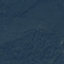

In [5]:
from PIL import Image
import os

folder = 'EuroSAT_data/EuroSAT/Forest'
first_image_name = os.listdir(folder)[0]
img = Image.open(os.path.join(folder, first_image_name))
print("Image size:", img.size)
img

In [3]:
!ls

sample_data


In [4]:
!kaggle datasets download -d apollo2506/eurosat-dataset

Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
100% 2.04G/2.04G [00:09<00:00, 227MB/s]



In [5]:
!unzip -q eurosat-dataset.zip -d EuroSAT_data
!ls EuroSAT_data/EuroSAT

AnnualCrop	      Highway	      Pasture	     River     train.csv
Forest		      Industrial      PermanentCrop  SeaLake   validation.csv
HerbaceousVegetation  label_map.json  Residential    test.csv


In [6]:
from torchvision import datasets
from torch.utils.data import random_split

full_dataset = datasets.ImageFolder(root='EuroSAT_data/EuroSAT', transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_set, val_set, test_set = random_split(full_dataset, [train_size, val_size, test_size])

print("Total images:", len(full_dataset))
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

Total images: 27000
Train: 21600 Val: 2700 Test: 2700


In [7]:
from torch.utils.data import Subset
import torch

full_dataset_train = datasets.ImageFolder(root='EuroSAT_data/EuroSAT', transform=train_transform)
full_dataset_test = datasets.ImageFolder(root='EuroSAT_data/EuroSAT', transform=test_transform)

train_size = int(0.8 * len(full_dataset_train))
val_size = int(0.1 * len(full_dataset_train))
test_size = len(full_dataset_train) - train_size - val_size

generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(full_dataset_train), generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size+val_size]
test_indices = indices[train_size+val_size:]

train_set = Subset(full_dataset_train, train_indices)
val_set = Subset(full_dataset_test, val_indices)
test_set = Subset(full_dataset_test, test_indices)

print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))

Train: 21600 Val: 2700 Test: 2700


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print("Data loaders ready.")

Data loaders ready.


In [14]:
print(model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [10]:
torch.cuda.is_available()

True

In [13]:
import torch.nn as nn
from torchvision import models

# Load ResNet50 with pretrained ImageNet weights
model = models.resnet50(weights='IMAGENET1K_V2')

# Freeze all existing layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final layer to output 10 classes instead of 1000
model.fc = nn.Linear(model.fc.in_features, 10)

# Move model to GPU
model = model.to(device)

print(model.fc)

Linear(in_features=2048, out_features=10, bias=True)


In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [15]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [16]:
epochs = 10

for epoch in range(epochs):
    # --- Training phase ---
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # --- Validation phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Epoch 1/10 | Train Loss: 0.6134, Train Acc: 82.44% | Val Loss: 0.3311, Val Acc: 90.33%
Epoch 2/10 | Train Loss: 0.3383, Train Acc: 89.44% | Val Loss: 0.2572, Val Acc: 92.63%
Epoch 3/10 | Train Loss: 0.2777, Train Acc: 90.95% | Val Loss: 0.2180, Val Acc: 93.56%
Epoch 4/10 | Train Loss: 0.2496, Train Acc: 91.69% | Val Loss: 0.1990, Val Acc: 93.48%
Epoch 5/10 | Train Loss: 0.2314, Train Acc: 92.36% | Val Loss: 0.1967, Val Acc: 93.70%
Epoch 6/10 | Train Loss: 0.2143, Train Acc: 92.88% | Val Loss: 0.1835, Val Acc: 94.30%
Epoch 7/10 | Train Loss: 0.2060, Train Acc: 93.25% | Val Loss: 0.1767, Val Acc: 94.26%
Epoch 8/10 | Train Loss: 0.1971, Train Acc: 93.40% | Val Loss: 0.1802, Val Acc: 94.41%
Epoch 9/10 | Train Loss: 0.1920, Train Acc: 93.54% | Val Loss: 0.1691, Val Acc: 94.52%
Epoch 10/10 | Train Loss: 0.1898, Train Acc: 93.67% | Val Loss: 0.1660, Val Acc: 94.41%
